In [12]:
import sys; sys.path.append("..")
from openbabel import openbabel as ob
import numpy as np
import pandas as pd
from matplotlib import pyplot as plt
from networkx.algorithms import isomorphism
import os
import vtk
from src import gimic_utils as gutils
from src import utils

In [2]:
def get_definition(structure: str):
    mol = utils.get_molecule(os.path.join("../data", "definitions", structure + ".mol"))
    return utils.mol_to_graph(mol)


def find_structure_indices(obmol: ob.OBMol, structure: str):
    subgraph = get_definition(structure)
    g = utils.mol_to_graph(obmol)
    iso = isomorphism.GraphMatcher(g, subgraph, node_match=utils.node_matcher)
    morph = list(iso.subgraph_isomorphisms_iter())
    return morph



In [ ]:
xyz_path = "../data/nmr/ATUSOX_0_out/gimic/mol.xyz"
mol = utils.get_molecule(xyz_path)
mol.DeleteHydrogens()

True

In [ ]:
jvec_vti_file = "../data/nmr/ATUSOX_0_out/gimic/jvec.vti"
vtk_data = gutils.read_vti_file(jvec_vti_file)

In [9]:
# Extract all metadata from vtk_data
print(vtk_data.GetInformation())


vtkInformation (0x55c603feeb50)
  Debug: Off
  Modified Time: 463
  Reference Count: 2
  Registered Events: (none)
  DATA_NUMBER_OF_GHOST_LEVELS: 0
  DATA_NUMBER_OF_PIECES: 1
  DATA_PIECE_NUMBER: 0
  DATA_EXTENT: 0 197 0 210 0 318
  DATA_EXTENT_TYPE: 1




In [10]:
while True:
    for atom in ob.OBMolAtomIter(mol):
        if atom.GetAtomicNum() == 1:
            mol.DeleteAtom(atom)
            break
    else:
        break
    
mol.ConnectTheDots()
porphyrin_atoms = list(find_structure_indices(mol, "porphyrins")[0].keys())
metal_idx = None
for atom_idx in porphyrin_atoms:
    atom = mol.GetAtom(atom_idx)
    if atom.GetAtomicNum() != 7:
        continue
    for nbr in ob.OBAtomAtomIter(atom):
        nbr_idx = nbr.GetIdx()
        if nbr_idx not in porphyrin_atoms and nbr.GetAtomicNum() != 7:
            metal_idx = nbr_idx
porphyrin_atoms.append(metal_idx)




Caching the list of root modules, please wait!
(This will only be done once - type '%rehashx' to reset cache!)



/home/shachar/miniconda3/envs/pymatgen/lib/python3.11/site-packages/IPython/core/completerlib.py:149: UserWarning: using rootmodules_cache requires you to install the `pickleshare` library.
  ip.db['rootmodules_cache'] = rootmodules_cache


In [13]:
def calculate_flux_through_bond(bond: ob.OBBond, vti_data: vtk.vtkImageData, surface_width: float, surface_height: float):
    """
    Calculates the flux of a vector field through a bond.

    Args:
        bond (ob.OBBond): An OpenBabel bond object.
        vti_file (str): Path to the .vti file containing the vector field.
        bond_radius (flat): Radius of bond to calcualte flux

    Returns:
        float: The flux of the vector field through the bond.
    """
    # extract the vector function
    vector_function = gutils.get_vector_function(vti_data)

    # Get the bond's start and end points
    atom1 = bond.GetBeginAtom()
    atom2 = bond.GetEndAtom()
    start = np.array([atom1.GetX(), atom1.GetY(), atom1.GetZ()])
    end = np.array([atom2.GetX(), atom2.GetY(), atom2.GetZ()])

    # Calculate the bond's center and direction
    center = (start + end) / 2
    direction = end - start
    normal = direction / np.linalg.norm(direction)

    # Calculate the flux through the bond
    return gutils.calculate_flux_through_plane_adaptive(vector_function, center, surface_width, surface_height, normal, N=10)

In [19]:
def calculate_bond_integrals(width, height, data):
    # print("Calculating with radius", bond_radius)
    bond_integrals = {}
    for atom_idx in porphyrin_atoms:
        atom_obj = mol.GetAtom(atom_idx)
        for nbr in ob.OBAtomAtomIter(atom_obj):
            nbr_idx = nbr.GetIdx()
            if nbr_idx in porphyrin_atoms and atom_idx < nbr_idx:
                bond = mol.GetBond(atom_obj.GetIdx(), nbr.GetIdx())
                integral = calculate_flux_through_bond(
                    bond, data, width, height
                )
                bond_integrals[(bond.GetBeginAtomIdx(), bond.GetEndAtomIdx())] = integral
    return bond_integrals

# Calculate bond integrals for bond_radius = 1, 2, 3, 4
widths = [1, 1.5, 2, 2.5, 3]
heights = [1, 1.5, 2, 2.5, 3]
ajr = []
for w in widths:
    for h in heights:
        print("running with w={}, h={}".format(w, h))
        ints = calculate_bond_integrals(w, h, vtk_data)
        ajr.extend([{"width": w, "height": h, "bond": k, "flux": v} for k, v in ints.items()])


# Create DataFrame with (atom1, atom2) as index and columns for each radius
df_bond_integrals = pd.DataFrame(ajr)
df_bond_integrals


running with w=1, h=1
running with w=1, h=1.5
running with w=1, h=2
running with w=1, h=2.5
running with w=1, h=3
running with w=1.5, h=1
running with w=1.5, h=1.5
running with w=1.5, h=2
running with w=1.5, h=2.5
running with w=1.5, h=3
running with w=2, h=1
running with w=2, h=1.5
running with w=2, h=2
running with w=2, h=2.5
running with w=2, h=3
running with w=2.5, h=1
running with w=2.5, h=1.5
running with w=2.5, h=2
running with w=2.5, h=2.5
running with w=2.5, h=3
running with w=3, h=1
running with w=3, h=1.5
running with w=3, h=2
running with w=3, h=2.5
running with w=3, h=3


,width,height,bond,flux
0,1.0,1.0,"(11, 13)",-0.140519
1,1.0,1.0,"(13, 15)",-0.019716
2,1.0,1.0,"(15, 20)",-0.049483
3,1.0,1.0,"(15, 16)",0.076233
4,1.0,1.0,"(16, 17)",0.002510
...,...,...,...,...
795,3.0,3.0,"(9, 10)",0.115187
796,3.0,3.0,"(9, 41)",-0.105214
797,3.0,3.0,"(44, 22)",0.054263
798,3.0,3.0,"(22, 43)",0.038727


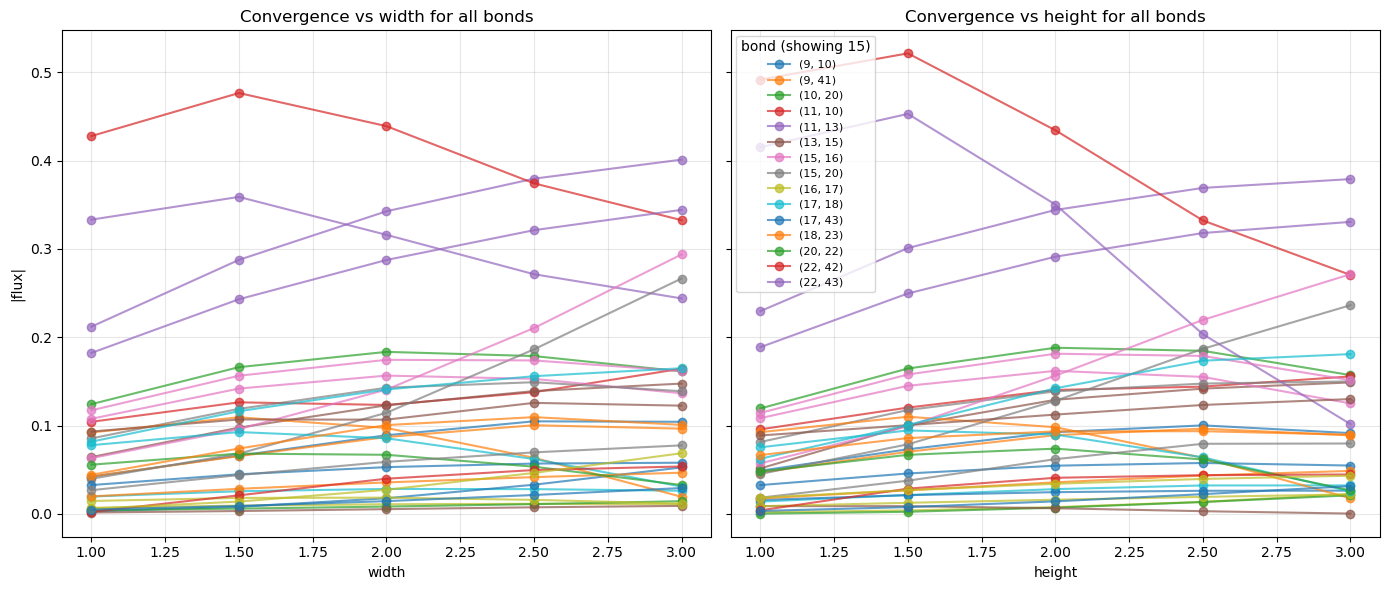

In [21]:
# Plot |flux| vs width and vs height for all bonds in the same plot

# Pivot the dataframe for easier plotting
pivot_w = df_bond_integrals.pivot_table(index="width", columns="bond", values="flux", aggfunc="mean")
pivot_h = df_bond_integrals.pivot_table(index="height", columns="bond", values="flux", aggfunc="mean")

fig, axes = plt.subplots(1, 2, figsize=(14, 6), sharey=True)

# |flux| vs width for each bond (one line per bond)
for bond in pivot_w.columns:
    axes[0].plot(pivot_w.index, pivot_w[bond].abs(), marker='o', label=str(bond), alpha=0.7)
axes[0].set_xlabel('width')
axes[0].set_ylabel('|flux|')
axes[0].set_title('Convergence vs width for all bonds')
axes[0].grid(True, alpha=0.3)

# |flux| vs height for each bond (one line per bond)
for bond in pivot_h.columns:
    axes[1].plot(pivot_h.index, pivot_h[bond].abs(), marker='o', label=str(bond), alpha=0.7)
axes[1].set_xlabel('height')
axes[1].set_title('Convergence vs height for all bonds')
axes[1].grid(True, alpha=0.3)

# Optionally, show legend for a subset of bonds to avoid clutter
handles, labels = axes[1].get_legend_handles_labels()
if len(labels) > 15:
    axes[1].legend(handles[:15], labels[:15], title='bond (showing 15)', fontsize=8)
else:
    axes[1].legend(title='bond', fontsize=8)

plt.tight_layout()
plt.show()


In [17]:
bond_integrals = calculate_bond_integrals(2, 3, vtk_data)

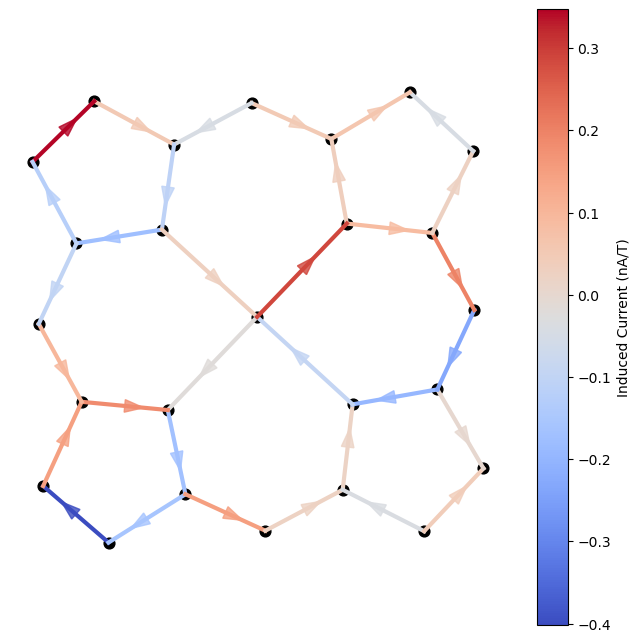

In [18]:
import numpy as np


# Get atom coordinates
# Fit a plane to the atom coordinates and project each atom onto the plane
coords_3d = np.array([[mol.GetAtom(atom_idx).GetX(), mol.GetAtom(atom_idx).GetY(), mol.GetAtom(atom_idx).GetZ()] for atom_idx in porphyrin_atoms])
centroid = coords_3d.mean(axis=0)
coords_centered = coords_3d - centroid
u, s, vh = np.linalg.svd(coords_centered)
normal = vh[2]
# Choose two orthogonal vectors in the plane for axes
plane_x = vh[0]
plane_y = vh[1]
# Project each atom onto the plane and get 2D coordinates
atom_coords = {
    atom_idx: (
        np.dot(coords_3d[i] - centroid, plane_x),
        np.dot(coords_3d[i] - centroid, plane_y)
    )
    for i, atom_idx in enumerate(porphyrin_atoms)
}

# Normalize bond integral values for coloring
integral_values = np.array(list(bond_integrals.values()))
vmin, vmax = integral_values.min(), integral_values.max()
norm = plt.Normalize(vmin, vmax)
cmap = plt.get_cmap('coolwarm')

fig, ax = plt.subplots(figsize=(8, 8))

# Draw bonds
for (a1, a2), val in bond_integrals.items():
    x1, y1 = atom_coords[a1]
    x2, y2 = atom_coords[a2]
    ax.plot([x1, x2], [y1, y2], color=cmap(norm(val)), linewidth=3)
    # Draw arrow at the center of the bond, pointing along the bond direction
    xm, ym = (x1 + x2) / 2, (y1 + y2) / 2
    dx, dy = 1e-6 * (x2 - x1) / 2, 1e-6 * (y2 - y1) / 2
    if val > 0:
        ax.arrow(xm, ym, dx, dy, color=cmap(norm(val)), width=0.05, length_includes_head=False, head_width=0.2, head_length=0.3, alpha=0.8)
    else:
        ax.arrow(xm, ym, -dx, -dy, color=cmap(norm(val)), width=0.05, length_includes_head=False, head_width=0.2, head_length=0.3, alpha=0.8)
    # Add text label above each bond with its value
    # xm, ym = (x1 + x2) / 2, (y1 + y2) / 2
    # direction = - (y1 - y2) / (x1 - x2)
    # direction = direction / abs(direction)
    # ax.text(xm, ym + direction * 0.15, f"{val:.1f}", fontsize=8, ha='center', va='bottom', color=cmap(norm(val)), fontweight='bold')

# Draw atoms
for atom_idx, (x, y) in atom_coords.items():
    ax.scatter(x, y, color='black', s=60)
    # ax.text(x, y, str(atom_idx), fontsize=8, ha='center', va='center', color='white')

ax.set_aspect('equal')
ax.axis('off')
sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm)
cbar = fig.colorbar(sm, ax=ax)
cbar.set_label("Induced Current (nA/T)")
plt.show()